# RCC Subtyping - Step 1: Data Preparation & Tissue Segmentation (Local)

In [ ]:
import os
import zipfile
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import gc
from pathlib import Path

# 路径
BASE_DIR = Path('/Users/zhangruikun/Desktop/BME515')
ZIP_PATH = BASE_DIR / 'DHMC_wsi_01.zip'
META_PATH = BASE_DIR / 'MetaData_Release_1.1.csv'
SLIDES_DIR = BASE_DIR / 'slides'
OUTPUT_DIR = BASE_DIR / 'segmentation_output'

SLIDES_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

print('路径设置完成')
print(f'ZIP: {ZIP_PATH.exists()}')
print(f'Metadata: {META_PATH.exists()}')

Matplotlib is building the font cache; this may take a moment.


路径设置完成
ZIP: True
Metadata: True


In [2]:
# 解压 zip（已解压则跳过）
if not any(SLIDES_DIR.glob('*.png')):
    print('正在解压，请稍等...')
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(SLIDES_DIR)
    print('解压完成')
else:
    print('已经解压过了')

slides = sorted(SLIDES_DIR.rglob('*.png'))
print(f'共找到 {len(slides)} 张 slide')

正在解压，请稍等...
解压完成
共找到 49 张 slide


In [3]:
# 读 metadata
meta = pd.read_csv(META_PATH)
print(meta.head())
print('\n各类别数量：')
print(meta['Diagnosis'].value_counts())

       File Name Diagnosis Slide Type Data Split
0  DHMC_0001.png    Benign  Resection        Val
1  DHMC_0002.png    Benign  Resection        Val
2  DHMC_0003.png    Benign  Resection        Val
3  DHMC_0004.png    Benign  Resection        Val
4  DHMC_0005.png    Benign  Resection        Val

各类别数量：
Diagnosis
Clearcell      344
Papillary      101
Oncocytoma      66
Benign          29
Chromophobe     23
Name: count, dtype: int64


In [4]:
# Otsu tissue segmentation 函数
def segment_tissue(img_path):
    img = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, mask = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    kernel = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    tissue_pct = mask.sum() / 255 / mask.size * 100
    return img_rgb, mask, tissue_pct

print('函数定义完成')

函数定义完成


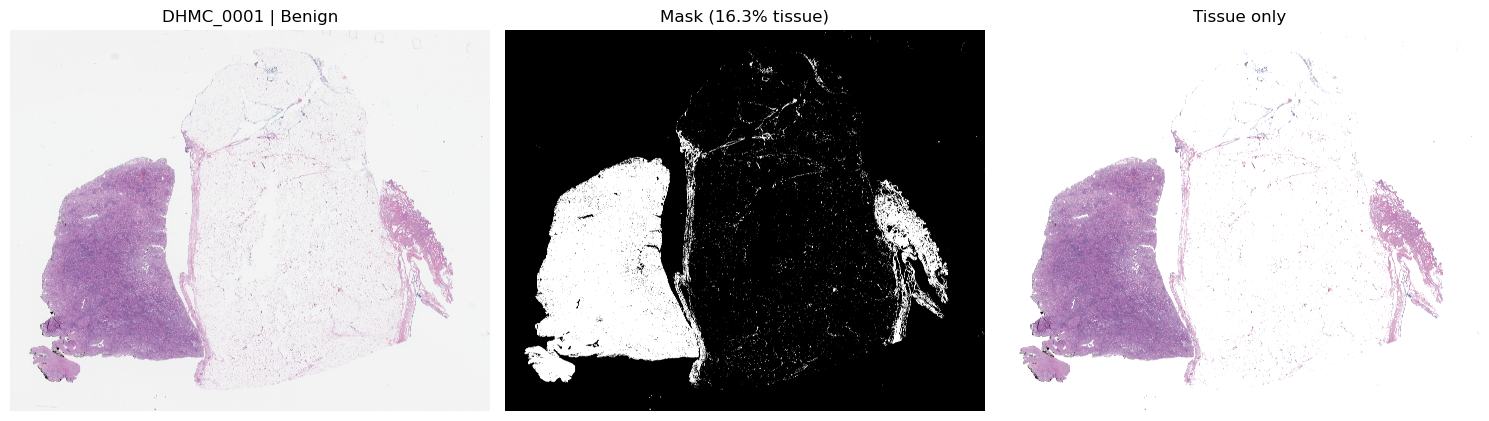

保存至 segmentation_output/preview_slide_0001.png


In [5]:
# 可视化第一张 slide
slide_path = slides[0]
img, mask, pct = segment_tissue(slide_path)

label = meta.loc[meta['File Name'] == slide_path.name, 'Diagnosis'].values
label = label[0] if len(label) > 0 else 'Unknown'

overlay = img.copy()
overlay[mask == 0] = 255

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img); axes[0].set_title(f'{slide_path.stem} | {label}'); axes[0].axis('off')
axes[1].imshow(mask, cmap='gray'); axes[1].set_title(f'Mask ({pct:.1f}% tissue)'); axes[1].axis('off')
axes[2].imshow(overlay); axes[2].set_title('Tissue only'); axes[2].axis('off')
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'preview_slide_0001.png'), dpi=80)
plt.show()

del img, mask, overlay
gc.collect()
print('保存至 segmentation_output/preview_slide_0001.png')

In [8]:
import gc
from pathlib import Path
import cv2
import numpy as np
import pandas as pd

MASK_DIR = BASE_DIR / 'masks'
MASK_DIR.mkdir(exist_ok=True)

results = []
for i, slide_path in enumerate(slides):
    _, mask, pct = segment_tissue(slide_path)

    # 保存 mask 为 PNG（白色=组织，黑色=背景）
    mask_save_path = MASK_DIR / slide_path.name
    cv2.imwrite(str(mask_save_path), mask)

    label = meta.loc[meta['File Name'] == slide_path.name, 'Diagnosis'].values
    label = label[0] if len(label) > 0 else 'Unknown'
    split = meta.loc[meta['File Name'] == slide_path.name, 'Data Split'].values
    split = split[0] if len(split) > 0 else 'Unknown'

    results.append({
        'file': slide_path.name,
        'diagnosis': label,
        'split': split,
        'tissue_pct': round(pct, 2)
    })

    del mask
    gc.collect()

    if (i + 1) % 10 == 0:
        print(f'{i+1}/{len(slides)} 处理完成')

df = pd.DataFrame(results)
df.to_csv(str(BASE_DIR / 'segmentation_output' / 'segmentation_summary.csv'), index=False)
print(f'\n全部完成，mask 保存在 masks/ 文件夹')
print(f'低组织含量 slides (<10%): {(df.tissue_pct < 10).sum()}')

10/49 处理完成
20/49 处理完成
30/49 处理完成
40/49 处理完成

全部完成，mask 保存在 masks/ 文件夹
低组织含量 slides (<10%): 0


In [9]:
PATCH_DIR = BASE_DIR / 'patches'
PATCH_DIR.mkdir(exist_ok=True)

PATCH_SIZE = 256       # 每个 patch 的大小
TISSUE_THRESHOLD = 0.5 # patch 里组织占比超过 50% 才保留

def extract_patches(slide_path, mask_path, patch_size=256, tissue_thresh=0.5):
    """
    读入 slide 和对应 mask，
    在有组织的区域切出 patch_size x patch_size 的小块。
    只保留组织占比超过 tissue_thresh 的 patch。
    返回保存的 patch 数量。
    """
    img = cv2.imread(str(slide_path))
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

    h, w = img.shape[:2]
    slide_name = slide_path.stem

    # 给这张 slide 建一个子文件夹
    slide_patch_dir = PATCH_DIR / slide_name
    slide_patch_dir.mkdir(exist_ok=True)

    count = 0
    for y in range(0, h - patch_size, patch_size):
        for x in range(0, w - patch_size, patch_size):
            mask_patch = mask[y:y+patch_size, x:x+patch_size]
            tissue_ratio = mask_patch.sum() / 255 / (patch_size * patch_size)

            if tissue_ratio >= tissue_thresh:
                img_patch = img[y:y+patch_size, x:x+patch_size]
                patch_name = f'{slide_name}_y{y}_x{x}.png'
                cv2.imwrite(str(slide_patch_dir / patch_name), img_patch)
                count += 1

    del img, mask
    gc.collect()
    return count

print('Patching 函数定义完成')

Patching 函数定义完成


DHMC_0001 切出了 240 个 patch


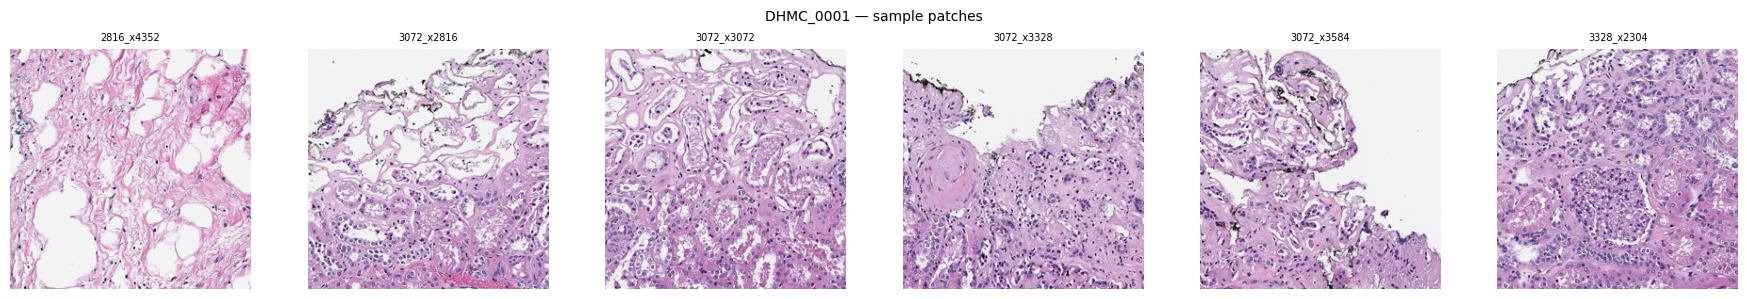

In [10]:
import matplotlib.pyplot as plt

# 先跑第一张，看看切出来的 patch 长什么样
test_slide = slides[0]
test_mask = MASK_DIR / test_slide.name

n = extract_patches(test_slide, test_mask, PATCH_SIZE, TISSUE_THRESHOLD)
print(f'{test_slide.stem} 切出了 {n} 个 patch')

# 随机显示 6 个 patch
patch_files = sorted((PATCH_DIR / test_slide.stem).glob('*.png'))[:6]
fig, axes = plt.subplots(1, 6, figsize=(18, 3))
for i, pf in enumerate(patch_files):
    p = cv2.cvtColor(cv2.imread(str(pf)), cv2.COLOR_BGR2RGB)
    axes[i].imshow(p)
    axes[i].axis('off')
    axes[i].set_title(pf.stem[-10:], fontsize=7)
plt.suptitle(f'{test_slide.stem} — sample patches', fontsize=10)
plt.tight_layout()
plt.show()

In [11]:
patch_summary = []
for i, slide_path in enumerate(slides):
    mask_path = MASK_DIR / slide_path.name
    n_patches = extract_patches(slide_path, mask_path, PATCH_SIZE, TISSUE_THRESHOLD)

    label = meta.loc[meta['File Name'] == slide_path.name, 'Diagnosis'].values
    label = label[0] if len(label) > 0 else 'Unknown'

    patch_summary.append({
        'file': slide_path.name,
        'diagnosis': label,
        'n_patches': n_patches
    })

    if (i + 1) % 10 == 0:
        print(f'{i+1}/{len(slides)} 完成')

df_patches = pd.DataFrame(patch_summary)
df_patches.to_csv(str(BASE_DIR / 'segmentation_output' / 'patch_summary.csv'), index=False)
print(df_patches)
print(f'\n总 patch 数: {df_patches.n_patches.sum()}')
print(f'平均每张 slide: {df_patches.n_patches.mean():.0f} patches')

10/49 完成
20/49 完成
30/49 完成
40/49 完成
             file    diagnosis  n_patches
0   DHMC_0001.png       Benign        240
1   DHMC_0002.png       Benign        449
2   DHMC_0003.png       Benign        616
3   DHMC_0004.png       Benign        758
4   DHMC_0005.png       Benign        475
5   DHMC_0006.png  Chromophobe       1048
6   DHMC_0007.png  Chromophobe        566
7   DHMC_0008.png  Chromophobe        807
8   DHMC_0009.png  Chromophobe       1115
9   DHMC_0010.png  Chromophobe        717
10  DHMC_0011.png    Clearcell        838
11  DHMC_0012.png    Clearcell       1138
12  DHMC_0013.png    Clearcell        620
13  DHMC_0014.png    Clearcell        749
14  DHMC_0015.png    Clearcell        716
15  DHMC_0016.png   Oncocytoma        437
16  DHMC_0017.png   Oncocytoma        744
17  DHMC_0018.png   Oncocytoma        546
18  DHMC_0019.png    Papillary        686
19  DHMC_0020.png    Papillary        550
20  DHMC_0021.png    Papillary        673
21  DHMC_0022.png    Papillary        39